Du filled [[0.8        0.8        0.79999999 ... 0.8        0.8        0.8       ]
 [0.8        0.8        0.79999999 ... 0.8        0.8        0.8       ]
 [0.8        0.8        0.8        ... 0.8        0.8        0.8       ]
 ...
 [0.8        0.8        0.8        ... 0.8        0.8        0.8       ]
 [0.8        0.8        0.79999999 ... 0.8        0.8        0.8       ]
 [0.8        0.8        0.79999999 ... 0.8        0.8        0.8       ]]


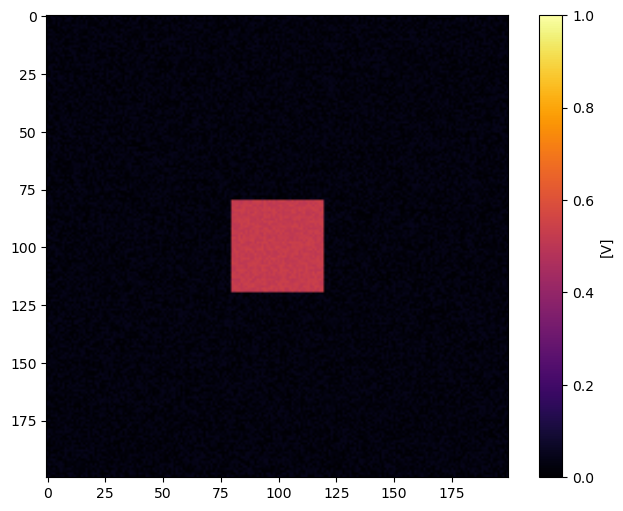

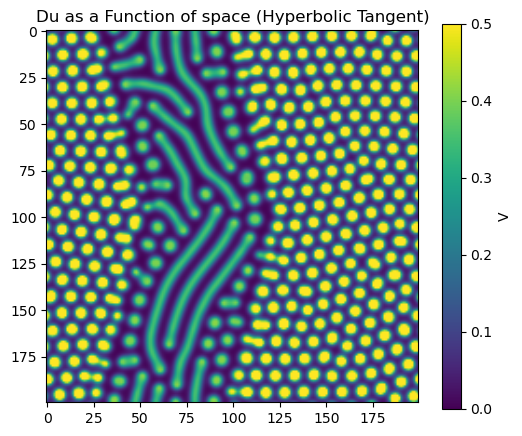

In [5]:
'''INPUTS'''

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

'''PARAMETERS'''

F, k =  0.046, 0.064 #(Stripes) #0.028, 0.064 (Dots) #0.010, 0.046 (Dynamic) #0.037, 0.06 (Standard)
N = 200
L = 200
dx = L / N
height = 5
dy = dx
n_steps =  200 #10000 #Using 300 for video. 
p1 = 50
p2 = 150
sharpness = 10 #this will control how sharp the chnage in concentration will be at the boundry p1 and p2
x = np.linspace(0,L,N,endpoint=False)
y = np.linspace(0,L,N,endpoint=False)

scale = 0.16
N = 200

Du = np.zeros((N,N))
transition = 10
x = np.linspace(0,L,N)
y = np.linspace(0,L,N)

X,Y = np.meshgrid(x,y)

'''FUNCTION DEFINTIONS'''

z1 = (4 * X + Y - 3*N//2) / transition
z2 = -(4 * X + Y - 3 * N) / transition
z3 = (-4 * X + Y + N//2) / transition
z4 = -(-4 * X + Y + 2*N) / transition 


tanh_bottom = ((height -1)/2) * (-1 * (np.tanh(z1) + np.tanh(z2)) + 2) + 1
tanh_top =  ((height -1)/2) * (np.tanh(z3) + np.tanh(z4) + 2) + 1


Du[0:N//2, :] = scale * tanh_top[0:N//2, :]
Du[N//2:N, :] = scale * tanh_bottom[N//2:N, :]
     

print('Du filled', Du)

Dv =  (np.min(Du)/2) * np.ones_like(Du)  # Dv = 0.08 For now I have placed Dv = Du/2 because that is the ratio we have been using so far. I still don't know why works, but it does.

dt = ((dx)**2)/(4 * Du.max())-0.1 #This is the time step, which is based on the diffusion constant. This is a function for the time step. 

'''DERVATIVES'''
def first_derivative(M, axis):
    firstD = (np.roll(M, 1, axis) - np.roll(M, -1, axis)) / (2 * dx)
    return firstD
        
def combined_derivative(D, Concentration):
    dD_dx = first_derivative(D, 0)
    dU_dx = first_derivative(Concentration, 0)
    dD_dy = first_derivative(D, 1)
    dU_dy = first_derivative(Concentration, 1)
    return dD_dx * dU_dx + dD_dy * dU_dy


def laplacian(Z, dx):
    d2Z_dx2 = np.roll(Z, 1, 0) - 2 * Z + np.roll(Z, -1, 0)
    d2Z_dy2 = np.roll(Z, 1, 1) - 2 * Z + np.roll(Z, -1, 1) 

    derivative = (d2Z_dx2 + d2Z_dy2)/(dx * dx) 
    # should this not be (d2Z_dx2/dx * dx) + (d2Z_dy2/dy * dy)? I think we are saying that 
    #dy = dx. So it doesn't matter and we combine like terms. 
    return derivative

def solver(U, V, Du, Dv, F, k, dx, dt):
    Lu = laplacian(U, dx)
    Lv = laplacian(V, dx)

    uvv = U * V * V

    U += (Du * Lu + combined_derivative(Du,U) - uvv + F * (1 - U)) * dt
    V += (Dv * Lv + combined_derivative(Dv,V) + uvv - (F+k) * V) * dt
    #Here is forward euler's method for the next time step. 
    return U, V
U = np.ones((N,N))
V = np.zeros((N,N))

'''START CONDITIONS'''
r = 20
U[N//2 - r:N//2+r, N//2 - r: N//2 + r] = 0.75 #orginally was 0.50
V[N//2 - r:N//2+r, N//2 - r: N//2 + r] = 0.50 #orginally was 0.25
U += 0.05 * np.random.rand(N,N)
V += 0.05 * np.random.rand(N,N)

fig, ax = plt.subplots(figsize=(8,6)) #regular sizing in a cube


'''COLOR BAR AND MAPPING'''
im = ax.imshow(V, cmap='inferno', interpolation='bilinear', vmin=0, vmax=1)
plt.axis('on')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('[V]')

def update(frame, U, V, Du, Dv, F, k, dx, dt):
    for _ in range(100):
        U, V = solver(U, V, Du, Dv, F, k, dx, dt)
    im.set_array(V)
    return [im] 

'''SOLVING'''

final_time = 1000
total_V_concentration = np.zeros(final_time)
total_time = np.zeros(final_time)

for i in range(final_time):
    for _ in range(100):
        U, V = solver(U, V, Du, Dv, F, k, dx, dt)
    
    total_time[i] = i * dt 
    total_V_concentration[i] = np.mean(V)


'''PLOTTING FINAL TIME STEP'''


tanh_func = Du
plt.figure(figsize=(6,5))
tanh_y = (tanh_func - tanh_func.min()) / (tanh_func.max() - tanh_func.min()) * (N - 1)

# x-coordinates: pixel indices (0 to N-1)
x_coords = np.arange(N)

# Overlay line: static sine curve
# tanh_line, = ax.plot(x_coords, tanh_y, color='white', linewidth=2, alpha=0.6)


plt.imshow(V, cmap='viridis', interpolation='bilinear', vmin=0, vmax=0.5)
plt.title('Du as a Function of space (Hyperbolic Tangent)')
plt.colorbar(label='V')
plt.show()


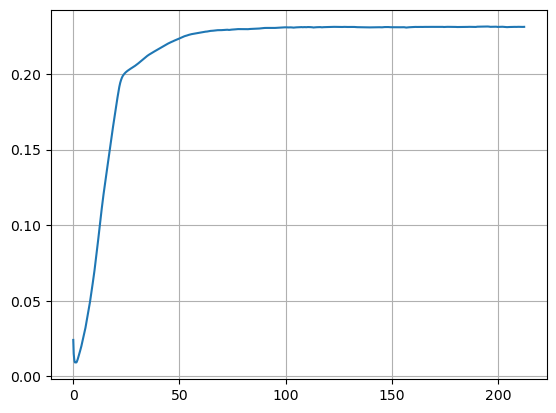

In [6]:
plt.figure()
plt.plot(total_time, total_V_concentration)
plt.grid(True)
plt.show()


(200,) (200, 200)


<>:28: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<>:29: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
/var/folders/ps/3vgc0wx14x5fc_xys26vj7wr0000gn/T/ipykernel_7165/3637311575.py:28: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
  mask1 = y2 > 4(x2 -25)


TypeError: 'int' object is not callable

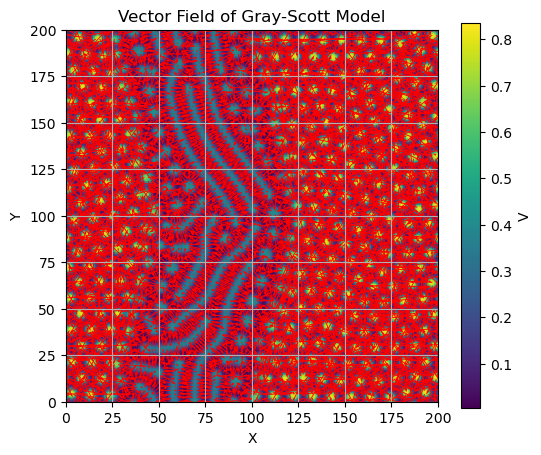

In [11]:
dVx = first_derivative(V, 1)
dVy = first_derivative(V, 0)


skip = 2 # keep as 4 regularly
print(x.shape, dVx.shape)

plt.figure(figsize=(6,5))
plt.imshow(V, cmap='viridis')
plt.title('Gray Scott')
plt.colorbar(label='V')
plt.xlim(0,200)
plt.ylim(0,200)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Vector Field of Gray-Scott Model')
plt.grid()

plt.quiver(x[::skip], y[::skip], dVx[::skip,::skip], dVy[::skip, ::skip], color='red', scale=3)

plt.plot()

x2, y2 = np.meshgrid(np.arange(N), np.arange(N))

# mask1 = x2 < p1
# mask2 = x2 > p2

mask1 = y2 > 4(x2 -25) 
mask2 = y2 < -4(x2-25) + 200

final_mask = mask1 | mask2

dVx2 =~final_mask * dVx
dVy2= ~final_mask * dVy

skip = 5
# Downsample both coordinate grids and vector components consistently
x_ds = x2[::skip, ::skip]
y_ds = y2[::skip, ::skip]
dVx_ds = dVx2[::skip, ::skip]
dVy_ds = dVy2[::skip, ::skip]

plt.figure(figsize=(6,5))
plt.imshow(V, cmap='viridis')
plt.colorbar(label='V')
plt.xlim(50,150)
plt.ylim(0, 200)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Vector Field of Gray-Scott Model')
plt.grid()

# Overlay vector field
plt.quiver(x_ds, y_ds, dVx_ds, dVy_ds, color='red', scale=1, width=0.005)

plt.plot()